In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('./Data/seasons_stats.csv', encoding = 'ISO-8859-1')
df
df.to_csv('./Data/readable_playerdata.csv')

In [16]:
#help(pd.DataFrame.groupby)

In [25]:
grouped = df.groupby('Player', as_index=False).agg({'Player':'first', 'Pos':'first','PER':'mean', 'USG%':'mean'})
grouped.head()

,Player,Pos,PER,USG%
0,A.C. Green,PF,13.872222,14.405556
1,A.J. Bramlett,C,-0.400000,17.100000
2,A.J. English,SG,11.550000,23.700000
3,A.J. Guyton,PG,4.366667,20.766667
4,A.J. Hammons,C,8.400000,17.600000


In [27]:
grouped.sort_values(by='PER', ascending=False).iloc[0:10,:][['Player', 'USG%', 'PER']]

,Player,USG%,PER
3939,Steven Hill,22.100000,88.300000
1793,Ian Lockhart,38.300000,76.300000
4222,Tyson Wheeler,28.400000,76.100000
1019,Dave Scholz,NaN,67.600000
656,Chad Gallagher,44.200000,66.800000
651,Cedric Lewis,33.500000,62.700000
858,Cozell McQueen,17.300000,58.300000
3192,Naz Mitrou-Long,26.133333,47.933333
343,Bill Stricker,NaN,45.100000
3850,Sim Bhullar,29.400000,44.300000


In [7]:
df.sort_values(by='PER', ascending=False).iloc[0:10,:][['Player', 'Pos', 'Age', 'PER', 'Year']]

,Player,Pos,Age,PER,Year
25045,Naz Mitrou-Long,SG,24.0,133.8,2018
22536,DeAndre Liggins,SG,25.0,129.1,2014
17109,Jackie Butler,C,19.0,90.3,2005
19522,Steven Hill,PF,23.0,88.3,2009
25840,Zhou Qi,PF,23.0,80.4,2019
2405,George Lee,F-G,30.0,77.0,1967
10203,Ian Lockhart,SF,23.0,76.3,1991
18894,Gerald Green,SF,22.0,76.3,2008
14390,Tyson Wheeler,PG,23.0,76.1,1999
11151,Alan Ogg,C,25.0,67.9,1993


In [104]:
goats = df[df['Player'].isin(['LeBron James', 'Michael Jordan*'])]
goats = goats.drop(columns='Unnamed: 0').reset_index()

In [105]:
goats.head()

,index,Year,Player,Pos,Age,Tm,G,GS,MP,FG,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,7681,1985,Michael Jordan*,SG,21.0,CHI,82,82.0,3144.0,837,...,13.0,29.8,10.3,3.7,14.0,0.213,6.8,1.4,8.2,8.1
1,8058,1986,Michael Jordan*,SG,22.0,CHI,18,7.0,451.0,150,...,10.5,38.6,1.0,0.5,1.5,0.160,5.1,-0.5,4.7,0.8
2,8432,1987,Michael Jordan*,SG,23.0,CHI,82,82.0,3281.0,1098,...,9.1,38.3,11.9,5.0,16.9,0.247,8.0,0.6,8.6,8.8
3,8831,1988,Michael Jordan*,SG,24.0,CHI,82,82.0,3311.0,1069,...,9.6,34.1,15.2,6.1,21.2,0.308,9.8,2.3,12.2,11.8
4,9258,1989,Michael Jordan*,SG,25.0,CHI,81,81.0,3255.0,966,...,11.9,32.1,14.6,5.2,19.8,0.292,9.8,2.7,12.6,12.0


In [106]:
def YearofC(row):
    player = row['Player']
    year = row['Year']
    
    if player == 'Michael Jordan*':
        yoc = (year - 1985) + 1
    elif player == 'LeBron James':
        yoc = (year - 2004) + 1
    else:
        yoc = None  # Handle other players (optional)
    
    return yoc

# Apply the function to each row
goats['Year of Career'] = goats.apply(YearofC, axis=1)
goats.head()

,index,Year,Player,Pos,Age,Tm,G,GS,MP,FG,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Year of Career
0,7681,1985,Michael Jordan*,SG,21.0,CHI,82,82.0,3144.0,837,...,29.8,10.3,3.7,14.0,0.213,6.8,1.4,8.2,8.1,1
1,8058,1986,Michael Jordan*,SG,22.0,CHI,18,7.0,451.0,150,...,38.6,1.0,0.5,1.5,0.160,5.1,-0.5,4.7,0.8,2
2,8432,1987,Michael Jordan*,SG,23.0,CHI,82,82.0,3281.0,1098,...,38.3,11.9,5.0,16.9,0.247,8.0,0.6,8.6,8.8,3
3,8831,1988,Michael Jordan*,SG,24.0,CHI,82,82.0,3311.0,1069,...,34.1,15.2,6.1,21.2,0.308,9.8,2.3,12.2,11.8,4
4,9258,1989,Michael Jordan*,SG,25.0,CHI,81,81.0,3255.0,966,...,32.1,14.6,5.2,19.8,0.292,9.8,2.7,12.6,12.0,5


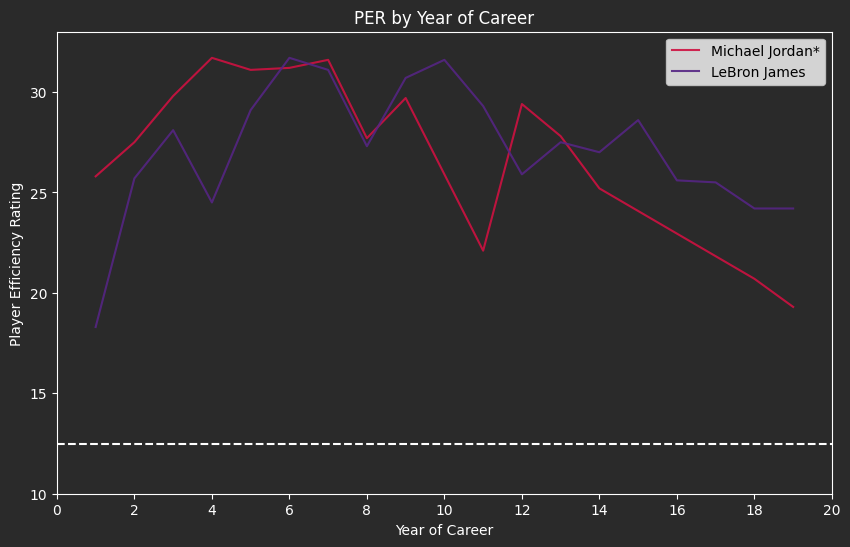

In [109]:
colors = ['#CE1141', '#552583']
fig, ax = plt.subplots(figsize=(10,6), facecolor='#2a2a2a')
sns.lineplot(data=goats, x='Year of Career', y='PER', hue='Player', palette=colors, ax=ax, alpha=.9)
ax.set_facecolor('#2a2a2a')
ax.tick_params(colors='white')
ax.set_ylabel('Player Efficiency Rating', color='white')
ax.set_xlabel('Year of Career', color='white')
ax.set_title('PER by Year of Career', color='White')
for spine in ax.spines.values():
    spine.set_color('white')

legend = ax.legend()
legend.get_frame().set_facecolor('white')
for text in legend.get_texts():
    text.set_color('black')

ax.set_xticks(range(0, 21, 2))
plt.axhline(12.5, label='League Average', color='white', linestyle='--')

ax.set_ylim((10,33))
plt.savefig('PER_by_year.pdf', format='pdf')

In [78]:
goats['PPG'] = goats['PTS'] /goats['G']
goats.to_csv('bron-jordan.csv')

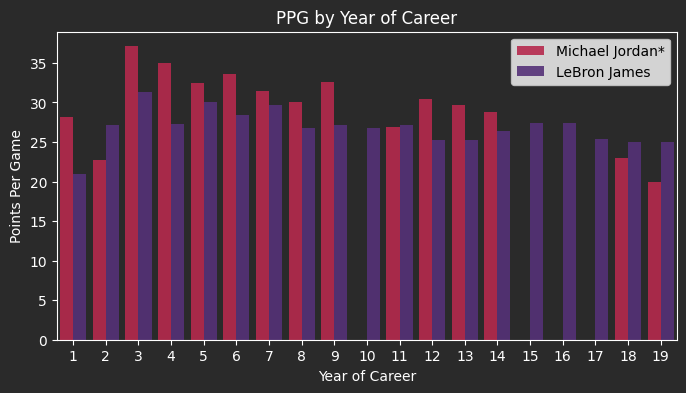

In [97]:
fig, ax = plt.subplots(figsize=(8,4), facecolor='#2a2a2a')
sns.barplot(data=goats, x='Year of Career', y='PPG', hue='Player', palette=colors, ax=ax, alpha=.9)
ax.set_facecolor('#2a2a2a')
ax.tick_params(colors='white')
ax.set_ylabel('Points Per Game', color='white')
ax.set_xlabel('Year of Career', color='white')
ax.set_title('PPG by Year of Career', color='White')
for spine in ax.spines.values():
    spine.set_color('white')

legend = ax.legend()
legend.get_frame().set_facecolor('white')
for text in legend.get_texts():
    text.set_color('black')

plt.savefig('PPG_by_year.pdf', format='pdf')

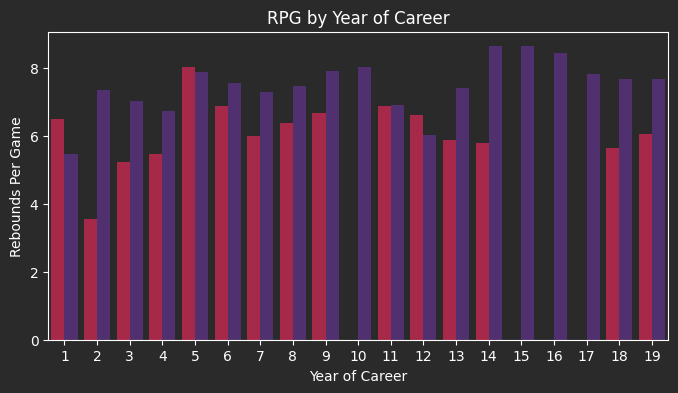

In [98]:
goats['RPG'] = goats['TRB'] /goats['G']
fig, ax = plt.subplots(figsize=(8,4), facecolor='#2a2a2a')
sns.barplot(data=goats, x='Year of Career', y='RPG', hue='Player', palette=colors, ax=ax, alpha=.9)
ax.set_facecolor('#2a2a2a')
ax.tick_params(colors='white')
ax.set_ylabel('Rebounds Per Game', color='white')
ax.set_xlabel('Year of Career', color='white')
ax.set_title('RPG by Year of Career', color='White')
for spine in ax.spines.values():
    spine.set_color('white')

# Add a legend
legend = ax.legend()

# Remove the legend
legend.remove()

plt.savefig('RPG_by_year.pdf', format='pdf')

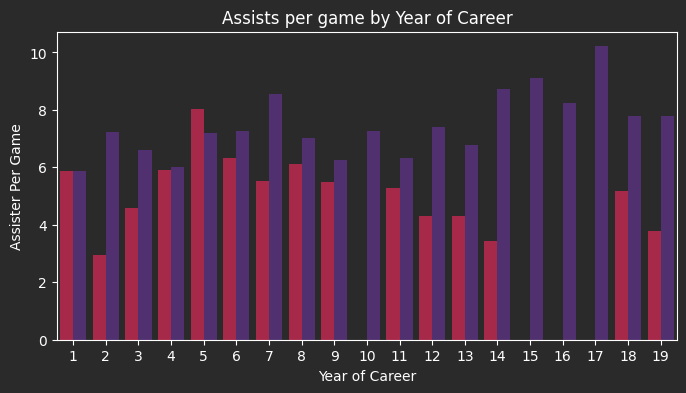

In [99]:
goats['APG'] = goats['AST'] /goats['G']
fig, ax = plt.subplots(figsize=(8,4), facecolor='#2a2a2a')
sns.barplot(data=goats, x='Year of Career', y='APG', hue='Player', palette=colors, ax=ax, alpha=.9)
ax.set_facecolor('#2a2a2a')
ax.tick_params(colors='white')
ax.set_ylabel('Assister Per Game', color='white')
ax.set_xlabel('Year of Career', color='white')
ax.set_title('Assists per game by Year of Career', color='White')
for spine in ax.spines.values():
    spine.set_color('white')

# Add a legend
legend = ax.legend()

# Remove the legend
legend.remove()
plt.savefig('APG_by_year.pdf', format='pdf')

C:\Users\danie\AppData\Local\Temp\ipykernel_14936\6734661.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Michael Jordan', 'Lebron James'], y = usage_avg, palette=colors, ax=ax)


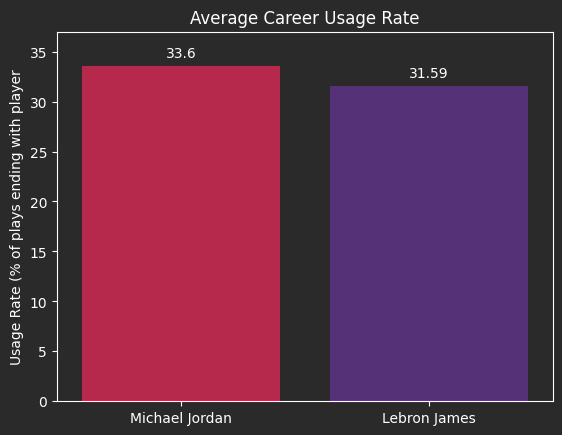

In [101]:
#Average usage rate
fig, ax = plt.subplots(facecolor = '#2a2a2a')
usage_avg = np.array([np.mean(goats[goats['Player']=='Michael Jordan*']['USG%']),np.mean(goats[goats['Player']=='LeBron James']['USG%'])])
usage_avg = np.round(usage_avg, 2)
sns.barplot(x=['Michael Jordan', 'Lebron James'], y = usage_avg, palette=colors, ax=ax)
for i, value in enumerate(usage_avg):
    plt.text(i, value + .5, str(value), ha='center', va='bottom', color='white')

ax.set_ylim((0,37))
ax.set_ylabel('Usage Rate (% of plays ending with player', color='white')
ax.set_title('Average Career Usage Rate', color='white')
ax.set_facecolor('#2a2a2a')
ax.tick_params(colors='white')

for spine in ax.spines.values():
    spine.set_color('white')

plt.savefig('mean_USG%.pdf', format='pdf')